In [ ]:
import numpy as np


import matplotlib.pyplot as plt

from pathlib import Path

import yaml

: 

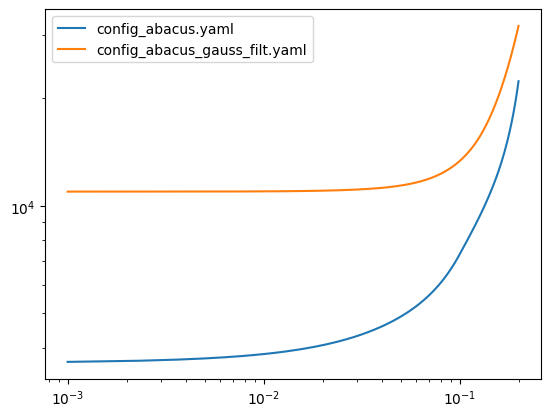

In [6]:
names = ['config_abacus.yaml', 'config_abacus_gauss_filt.yaml']

for name in names:
    with open(name, 'r') as f:
        config = yaml.safe_load(f)
    gen_nl_power = np.loadtxt(config['power_spectrum']['nonlinear'])

    output_config = config['output']
    filename_prefix = output_config['filename_prefix']
    filename_prefix = output_config['filename_prefix']
    output_dir = Path(output_config['directory'])/config['name']
    out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
    out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()

    kr_config = config['k_range']
    kmin = kr_config['kmin']
    kmax = kr_config['kmax']
    k_samples = kr_config['k_samples']
    k_min_analysis = kr_config['k_min_analysis']
    k_max_analysis = kr_config['k_max_analysis']

    Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

    key = "g"
    kinds = ["s", "t", "g"]
    N = out_normalization_AB[(key, key)]**-1.
    v = out_variance_AB[(key, key)]

    plt.loglog(Ks, N, label = name)

plt.legend()